# Week2-1: 6D MCMC from scratch

Now we have the position of all the stars in the 1x1 degree on the sky. \
We assume that each star could belong ot the dwarf galaxy that follows a Gaussian distribution or a the MW forground that follows a flat distribution. \
Now we will determine the 2D distribution of dwarf galaxies on the sky, as well as the member probability of each star. 



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner

%matplotlib inline

In [2]:
data_path = '../data/Dwarfs/'
res_path = '../result/'
fig_path = '../figure/'


df = pd.read_csv(data_path+'Dwarf_01')

df

,X_pc,Y_pc,vr,d_vr,FeH,d_FeH,flag
0,862.072,-267.376,-2.177,4.46,-2.13,0.23,1
1,-108.093,-117.081,999.000,999.00,-2.08,0.26,1
2,254.962,-410.536,999.000,999.00,-2.13,0.30,1
3,337.575,-492.211,999.000,999.00,-2.11,0.25,1
4,-329.291,-491.952,999.000,999.00,-2.44,0.25,1
...,...,...,...,...,...,...,...
2131,4776.443,976.284,999.000,999.00,-0.39,0.21,0
2132,4899.896,-3715.461,-55.157,4.43,-0.59,0.24,0
2133,-2399.821,-3014.935,999.000,999.00,-0.73,0.27,0
2134,56.823,2569.389,999.000,999.00,-0.77,0.24,0


## Check the data first

The dwarf galaxy looks very elliptical, so that we need more parameters!

(-2000.0, 2000.0)

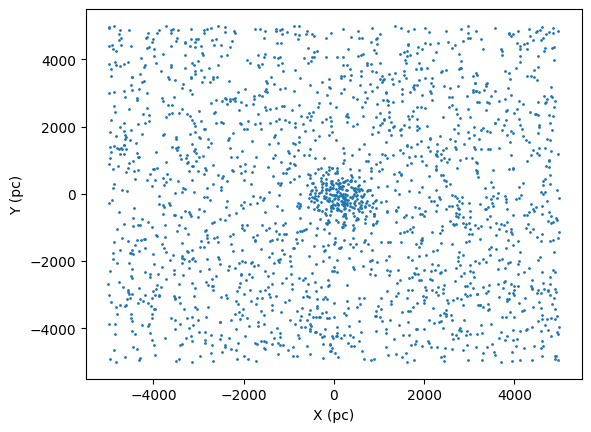

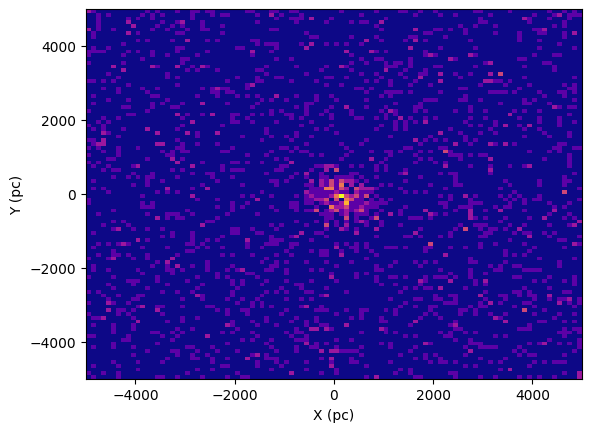

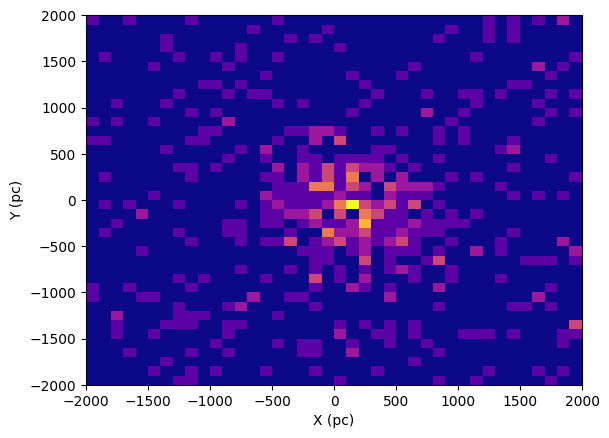

In [3]:
plt.figure()
plt.scatter(df['X_pc'], df['Y_pc'], s=1)

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=100, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=100, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.xlim(-2000, 2000)
plt.ylim(-2000, 2000)


In [4]:
def new_coords(x, y, alpha):

    x_new = x * np.cos(alpha) + y * np.sin(alpha)
    y_new = - x * np.sin(alpha) + y * np.cos(alpha)

    return x_new, y_new

# define the two axis of the ellipse using sigma_x, sigma_y, and alpha (change within pi/2)
def log_Likelihood(theta, x, y):

    xc, yc, sigma_x, sigma_y, alpha, f = theta

    x1, y1 = new_coords(x, y, alpha)
    xc1, yc1 = new_coords(xc, yc, alpha)

    # Calculate the likelihood of being in the dwarf galaxy
    L1 = f/(2*np.pi*sigma_x * sigma_y)*np.exp(-0.5*((x1-xc1)**2./sigma_x**2.+(y1-yc1)**2./sigma_y**2.))
    # Calculate the likelihood of being in the MW foreground
    L2 = (1-f)/10000**2.
    
    logL = np.sum(np.log(L1 + L2))

    return logL


In [12]:
xc0 = 0
yc0 = 0
sigma_x0 = 100
sigma_y0 = 100
alpha0 = 0
f0=0.1
param0 = xc0, yc0, sigma_x0, sigma_y0, alpha0, f0

logL0 = log_Likelihood(param0, df['X_pc'], df['Y_pc'])

# refine the following steps based on the uncertainties of the results
step_xc = 30
step_yc = 30
step_sigma_x = 30
step_sigma_y = 30
step_alpha = np.pi/20
step_f = 0.01

nsteps = 50000

samples = np.zeros((nsteps, 8))
accept = 1

In [13]:
for i in range(nsteps):

    param1 = param0
    logL1 = logL0

    samples[i, :6] = param1
    samples[i, 6] = logL1
    samples[i, 7] = accept

    accept = 0

    xc1, yc1, sigma_x1, sigma_y1, alpha1, f1 = param1
    xc1 = xc1 + np.random.normal(0, step_xc)   
    yc1 = yc1 + np.random.normal(0, step_yc)
    sigma_x1 = sigma_x1 + np.random.normal(0, step_sigma_x)
    sigma_y1 = sigma_y1 + np.random.normal(0, step_sigma_y)
    alpha1 = alpha1 + np.random.normal(0, step_alpha)

    f1 = f1 + np.random.normal(0, step_f)
    param1 = xc1, yc1, sigma_x1, sigma_y1, alpha1, f1

     # assuming the axis changing from 0 to pi/2, may need to adjust to (-pi/4 to pi/4) for some dwarfs

    if (0 < f1 < 1) & (0 <sigma_x1 < 1000) & (0 < sigma_y1 < 1000) & (0 <= alpha1 < np.pi/2) :
    
        logL1 = log_Likelihood(param1,  df['X_pc'], df['Y_pc'])      

        if logL1 > logL0:

            param0 = param1
            logL0 = logL1
            accept = 1

        else:

            a = np.random.uniform(0, 1)
            if (logL1-logL0) > np.log(a):

                param0 = param1
                logL0 = logL1
                accept = 1

In [14]:
# Check the acceptance rate of the MCMC (should be around 20%)
ind_accept = samples[:, -1] == 1
print ("acceptance rate", len(samples[ind_accept, -1])/nsteps)


acceptance rate 0.2488


In [15]:
samples =  samples[int(nsteps*0.1):]
np.savetxt(res_path+'Dwarf_%02d_6D_MCMC_chain.txt'%1, samples)

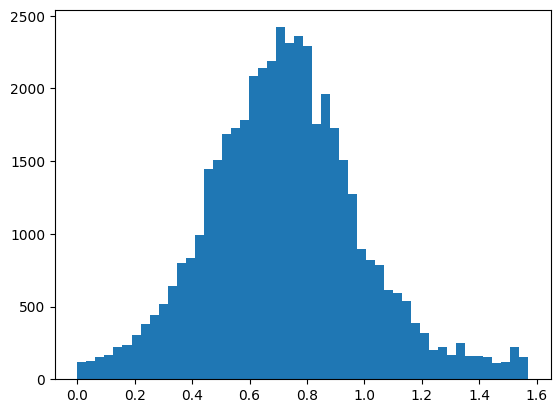

In [16]:
# Check the tilted angle first, because we may change the range of plotting
alpha_chain = samples[:,4]
plt.figure()
plt.hist(alpha_chain, bins=50);

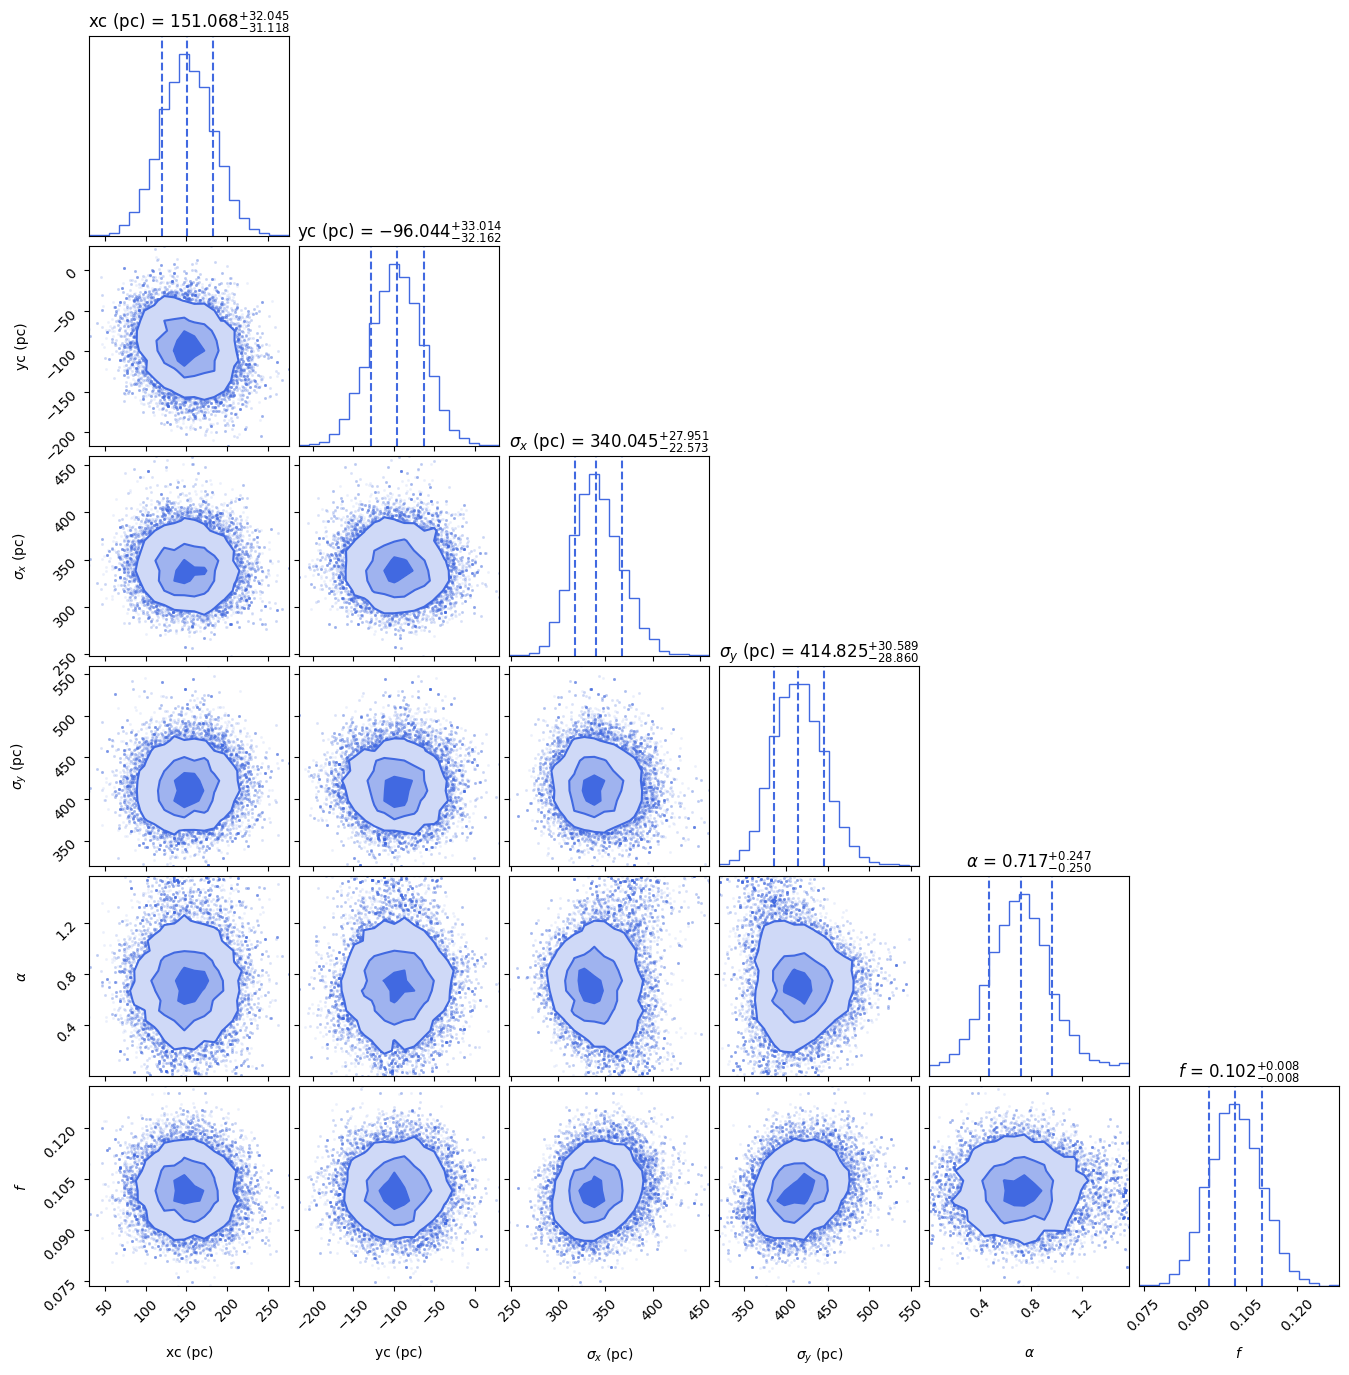

In [17]:
figure_path="../figure/"
fig = corner.corner(
    samples[:,:6],
    labels=[r"xc (pc)", r"yc (pc)", r"$\sigma_x$ (pc)", r"$\sigma_y$ (pc)", r"$\alpha$", r"$f$"],
    # truths=[mvr1_true, dvr1_true, mvr2_true, dvr2_true, f_true],  # optional
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True
)

plt.savefig(figure_path+'Dwarf_%02d_6D_MCMC_corner.png'%1, dpi=300)

## Check if the model represents the data well

201 201 (200, 200)


(-1000.0, 1000.0)

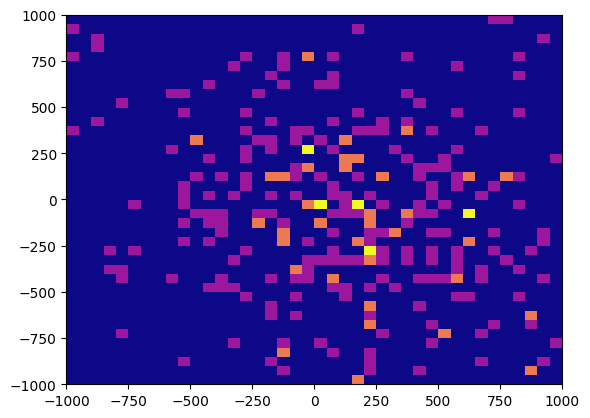

In [18]:
h, xbins, ybins = np.histogram2d(df['X_pc'], df['Y_pc'], bins=[200, 200])
print (len(xbins), len(ybins), h.shape)
plt.figure()
poly = plt.pcolormesh(xbins, ybins, h.T, cmap='plasma');
plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)


In [19]:
param_f = np.zeros(6)
for i in range(6):

    param_f[i] = np.percentile(samples[:,i], 50)
print (param_f)

L_bin = np.zeros((200, 200))
xc_bin =(xbins[:-1] + xbins[1:])*0.5
yc_bin =(ybins[:-1] + ybins[1:])*0.5

for i in range(200):

    for j in range(200):
                   
        L_bin[i, j] = np.exp(log_Likelihood(param_f, xc_bin[i], yc_bin[j])) * (10000/200)**2. * len(df)

[ 1.51067636e+02 -9.60439167e+01  3.40044542e+02  4.14825352e+02
  7.17003991e-01  1.01848439e-01]


(-1000.0, 1000.0)

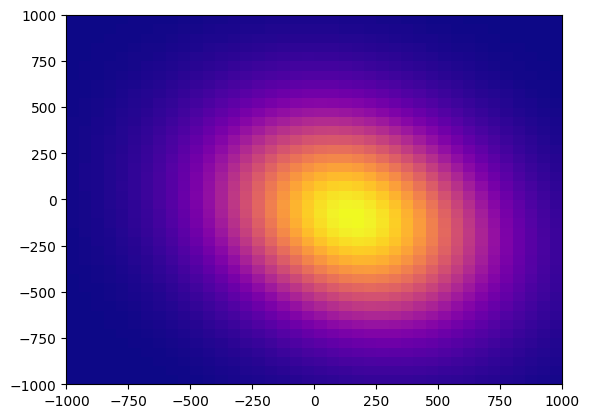

In [20]:
plt.figure()
poly = plt.pcolormesh(xbins, ybins, L_bin.T, cmap='plasma');

plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)

## Calculating the membership probabilities

In [24]:
def prob_member(theta, x, y):

    xc, yc, sigma_x, sigma_y, alpha, f = theta

    x1, y1 = new_coords(x, y, alpha)
    xc1, yc1 = new_coords(xc, yc, alpha)

    # Calculate the likelihood of being in the dwarf galaxy
    p1 = 1/(2*np.pi*sigma_x * sigma_y)*np.exp(-0.5*((x1-xc1)**2./sigma_x**2.+(y1-yc1)**2./sigma_y**2.))
    # Calculate the likelihood of being in the MW foreground
    p2 = 1/10000**2.
    
    prob = p1 / (p1 + p2)

    return prob


In [22]:
ind_max = np.argmax(samples[:,-2])
param_best = samples[ind_max,:6]

print (param_best)


p_member1 = np.zeros(len(df))

p_member1 = prob_member(param_best, df['X_pc'], df['Y_pc'])


[ 1.47160454e+02 -1.06257395e+02  3.32877000e+02  4.08709899e+02
  7.15742833e-01  1.00766598e-01]


In [25]:
p_member2 = np.zeros(len(df))
indices = np.random.choice(len(samples), 1000, replace=False)
print(indices.shape)
draw_samples = samples[indices]



for i in range(len(draw_samples)):

    param = draw_samples[i,:6]

    p_member2 += prob_member(param, df['X_pc'], df['Y_pc'])

p_member2 = p_member2/len(draw_samples)
df['P_member'] = p_member2



(1000,)


Text(0, 0.5, 'Pmember (marginalized over all models)')

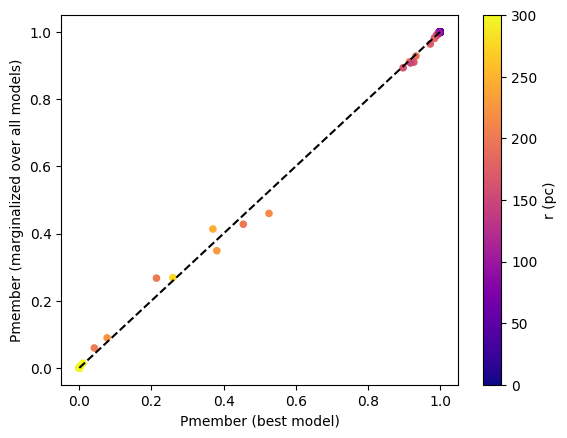

In [ ]:
plt.figure()
im=plt.scatter(p_member1, p_member2, c=np.sqrt((df["X_pc"]-param_best[0])**2.+(df["Y_pc"]-param_best[1])**2.), s=20, cmap="plasma", vmin=0, vmax=300)
plt.colorbar(im, label="r (pc)")
plt.plot((0,1), (0,1), color="k", ls= "dashed")
plt.xlabel("Pmember (best model)")
plt.ylabel("Pmember (marginalized over all models)")

Text(0.5, 0, 'Probability of being a member of Dwarf02')

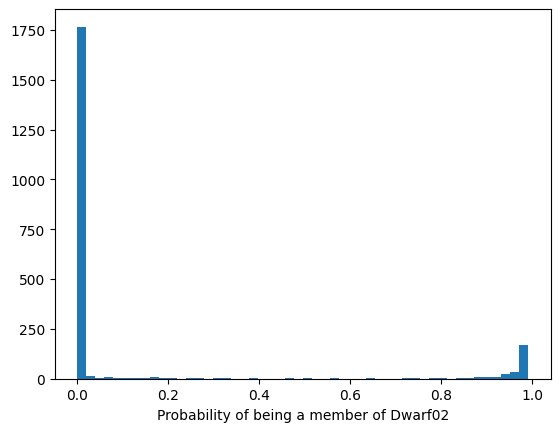

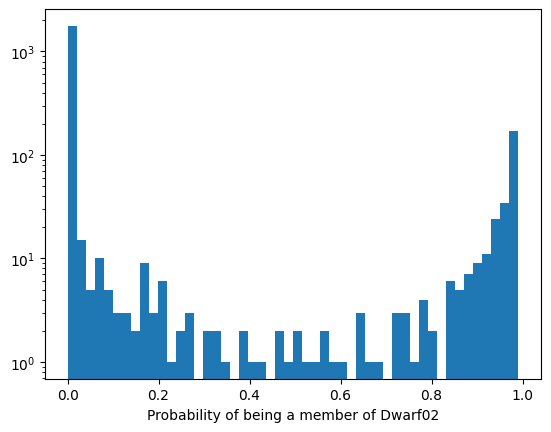

In [26]:
plt.figure()
plt.hist(p_member2, bins=50);
plt.xlabel("Probability of being a member of Dwarf%02d"%2)

plt.figure()
plt.hist(p_member2, bins=50);
plt.yscale("log")
plt.xlabel("Probability of being a member of Dwarf%02d"%2)

(-2000.0, 2000.0)

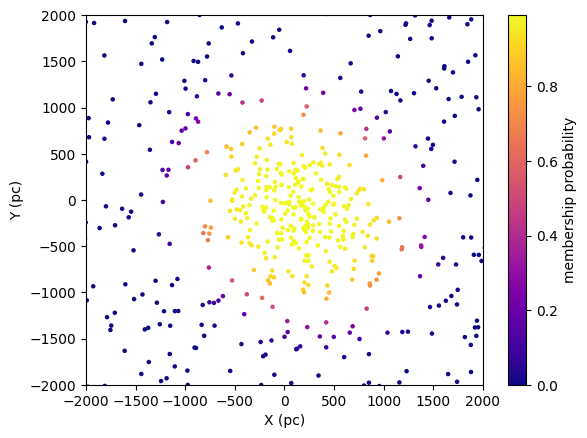

In [28]:
plt.figure()
im=plt.scatter(df['X_pc'], df['Y_pc'], c=df['P_member'], s=5, cmap='plasma')
cb=plt.colorbar(im)
cb.set_label("membership probability")

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")

plt.xlim(-2000, 2000)
plt.ylim(-2000, 2000)